In [24]:
import sys
import os

sys.path.append('/scratch2/mrenaudin/colorlessgreenRNNs')

import torch
from wm_tests.utils import CBR_RNN_attn_tracking
from src.language_models.dictionary_corpus import Dictionary
from evaluation_notebooks.utils import NounPPDataset, collate_fn_nounpp
from torch.utils.data import DataLoader
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch.nn as nn
import logging
import math

In [25]:
class CBR_RNN_attn_tracking(nn.Module):
    # goal here is to reuse CBR_RNN but with scaled dot product attention for more efficient computations.
    # Also I got rid of options such as loading pretrained embeddings, and ablating attention to simplify the code.
    # In the future if those options are needed, they can still be copy pasted from William's code as the structure hasn't changed
    def __init__(self, ntoken, ninp, nhid, nheads, dropout=0.5, device=None):
        super().__init__()
        # same layers as Timkey
        self.device = device
        self.nheads = nheads
        self.tanh = nn.Tanh()
        self.drop = nn.Dropout(dropout)
        self.score_attn = nn.Softmax(dim=-1)
        self.encoder = nn.Embedding(ntoken, ninp)
        self.q = nn.Linear(ninp + nhid, nhid)
        self.intermediate_h = nn.Linear(nhid * 4, nhid * 4)
        self.decoder = nn.Linear(nhid, ntoken)
        self.q_norm = torch.nn.LayerNorm(nhid)
        self.int_norm = torch.nn.LayerNorm(nhid * 4)
        self.f_norm = torch.nn.LayerNorm(nhid * 3)
        self.nhid = nhid
        self.final_h = nn.Linear(nhid * 4, nhid * 3)
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=nhid, num_heads=nheads, batch_first=True
        )

        self.init_weights()

    def init_weights(self):
        """Initialize model weights for better training dynamics"""
        # General initialization
        for name, param in self.named_parameters():
            if "weight" in name:
                if "norm" in name:
                    nn.init.ones_(param)
                elif "encoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                elif "decoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                else:
                    # Standard He initialization for processing layers
                    nn.init.kaiming_normal_(param, mode="fan_in", nonlinearity="tanh")
            elif "bias" in name:
                nn.init.zeros_(param)

    def init_cache(self, observation, nheads):
        """Initialize hidden state and attention caches with better initialization strategy"""
        if len(observation.size()) > 1:
            bsz = observation.size(dim=-1)
        else:
            bsz = 1

        hidden = torch.zeros(1, bsz, self.nhid).to(self.device) 
        if nheads == 1:
            key_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
        else:
            key_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
        return hidden, key_cache, value_cache


    def update_cache(self, key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads):
        hidden_i = hidden_i.unsqueeze(0)
        hidden = torch.cat((hidden, hidden_i), dim=0)
        if nheads == 1:
                key_cache_i = key_cache_i.unsqueeze(1).unsqueeze(1)
                value_cache_i = value_cache_i.unsqueeze(1).unsqueeze(1)
                key_cache = torch.cat((key_cache, key_cache_i), dim=2)
                value_cache = torch.cat((value_cache, value_cache_i), dim=2)
        else:
            key_cache_i = key_cache_i.unsqueeze(1)
            value_cache_i = value_cache_i.unsqueeze(1)
            key_cache = torch.cat((key_cache, key_cache_i), dim=1)
            value_cache = torch.cat((value_cache, value_cache_i), dim=1)
            
        return key_cache, value_cache, hidden
    
    @staticmethod
    def temperature_attention(query, key, value, temperature, gumbel_softmax=None, attn_mask=None,dropout_p=0.0,
        is_causal=False, scale=None, enable_gqa=False) -> torch.Tensor:
        L, S = query.size(-2), key.size(-2)
        scale_factor = 1 / math.sqrt(query.size(-1)) if scale is None else scale
        attn_bias = torch.zeros(L, S, dtype=query.dtype, device=query.device)
        if is_causal:
            assert attn_mask is None
            temp_mask = torch.ones(L, S, dtype=torch.bool).tril(diagonal=0)
            attn_bias.masked_fill_(temp_mask.logical_not(), float("-inf"))
            attn_bias.to(query.dtype)

        if attn_mask is not None:
            if attn_mask.dtype == torch.bool:
                attn_bias.masked_fill_(attn_mask.logical_not(), float("-inf"))
            else:
                attn_bias = attn_mask + attn_bias

        if enable_gqa:
            key = key.repeat_interleave(query.size(-3)//key.size(-3), -3)
            value = value.repeat_interleave(query.size(-3)//value.size(-3), -3)

        attn_weight = query @ key.transpose(-2, -1) * scale_factor
        attn_weight += attn_bias
        if gumbel_softmax: 
            attn_weight = torch.gumbel_softmax(attn_weight, tau=temperature, hard=False, dim=-1)
        else : 
            attn_weight = attn_weight/temperature
            attn_weight = torch.softmax(attn_weight, dim=-1)
        attn_weight = torch.dropout(attn_weight, dropout_p, train=True)
        return attn_weight, attn_weight @ value
    
    def attention_layer(self, query, key_cache, value_cache, nheads, temperature, gumbel_softmax):
        if nheads == 1:
                query = query.unsqueeze(1)
                
                # Ensure all tensors are on the same device
                if query.device != key_cache.device:
                    key_cache = key_cache.to(query.device)
                if query.device != value_cache.device:
                    value_cache = value_cache.to(query.device)
                if temperature is None:  
                    try:
                        attn_output = scaled_dot_product_attention(
                            query, key_cache, value_cache, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)
                else:
                    try:
                        attn_weight, attn_output = self.temperature_attention(
                            query, key_cache, value_cache, temperature, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)

            
        else:
            attn_output, _ = self.multihead_attn(
                query, key_cache, value_cache, is_causal=False
            )
            attn = attn_output.squeeze(1)
            del attn_output  # No longer needed after squeezing
            query = query.squeeze(1)
            
        return attn_weight, attn, query
    
    def intermediate_layers(self, i, emb, query, attn, hidden):
        intermediate_input = torch.cat((emb[i], query, attn, hidden[-1]), -1)
        del query, attn  
        intermediate = self.drop(
            self.tanh(self.int_norm(self.intermediate_h(intermediate_input)))
        )
        del intermediate_input  
        final_output = self.drop(self.tanh(self.f_norm(self.final_h(intermediate))))
        del intermediate  
        key_cache_i, value_cache_i, hidden_i = final_output.split(self.nhid, dim=-1)
        del final_output
        return key_cache_i, value_cache_i, hidden_i
    
    def get_query(self, emb, hidden):
        combined = torch.cat((emb, hidden[-1]), -1)
        query = self.drop(self.tanh(self.q_norm(self.q(combined))))
        del combined  # No longer needed after creating query
        query = query.unsqueeze(1)
        return query
    
    def forward(self, observation, initial_cache, nheads, temperature, gumbel_softmax):
        seq_len = observation.size(0)
        hidden, key_cache, value_cache = initial_cache

        # 1. Encode observations
        emb = self.drop(self.encoder(observation))
        del observation  # No longer needed after encoding
        attn_weights = []
        attention=[]
        hidden_states=[]
        for i in range(seq_len):
            # 2. Concatenate with previous hidden state

            
            query = self.get_query(emb[i], hidden)
            
            attn_weight, attn, query = self.attention_layer(query, key_cache, value_cache, nheads, temperature, gumbel_softmax)
            attn_weights.append(attn_weight)
            attention.append(attention)
            key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attn, hidden)
            hidden_states.append(hidden_i)
            key_cache, value_cache, hidden = self.update_cache(key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads)
            
            del key_cache_i, value_cache_i, hidden_i  # No longer needed after concatenation

        decoded = self.decoder(hidden[1:])

        return decoded, hidden_states, attn_weights, attention

In [26]:
#model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CBR_RNN_attn_tracking(50001, 1024, 1024, 1, device = device)
checkpoint = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/test_attention_1024/epoch_28.pt', map_location=device)
temperature = checkpoint['epoch']
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [27]:
#NounPP dataset
nounpp = '/scratch2/mrenaudin/colorlessgreenRNNs/NounPP/Stimuli/nounpp.txt'
data = '/scratch2/mrenaudin/colorlessgreenRNNs/english_data'
dictionary = Dictionary(data)
dataset = NounPPDataset(nounpp, dictionary)
dataloader = DataLoader(dataset, batch_size=1000, collate_fn=collate_fn_nounpp)

In [28]:
def eval(model, test_dataloader, temperature):
    condition_accuracies = defaultdict(int)
    condition_counts = defaultdict(int)
    correct_pred = 0
    sentence_details = []
    model.eval()
    features = {}
    features['hidden']=[]
    features['attention_weights']= []
    features['attention']= []
    features['condition']=[]
    # Forward pass with hidden state update word by word
    with torch.no_grad():
        for batch in test_dataloader:
            out = None
            written = batch["sentence"]
            sentence = batch["encoded_sentence"]
            correct = batch["encoded_correct"]
            wrong = batch["encoded_wrong"]
            condition = batch["condition"]
            batch_size = sentence.size(0)
            features['condition'].append(condition)
            sent = sentence.transpose(0, 1)
            cache = model.init_cache(sent,1)  # regarder si on peut mettre du priming
            # for i in range(sent.shape[1]):
            out, hidden, attention_weights, attention= model(sent, cache, 1, temperature, True)
            features['hidden'].append(hidden)
            features['attention'].append(attention)
            features['attention_weights'].append(attention_weights)
            log_probs = torch.nn.functional.log_softmax(
                out, dim=-1
            )  # s(out.squeeze(0))
            # déja sur correct et wrong log probs, pas les même résultats que sur extract_predictions.py
            correct_log_probs = log_probs[
                -1, torch.arange(batch_size), correct
            ]  # Shape: [512]
            wrong_log_probs = log_probs[-1, torch.arange(batch_size), wrong]
            correct_predictions = correct_log_probs >= wrong_log_probs

            for i in range(batch_size):
                cond = condition[i]
                pred = correct_predictions[i].item()  # Convert tensor to Python boolean
                condition_counts[cond] += 1
                condition_accuracies[cond] += pred

                sentence_details.append(
                    {
                        "sentence": written[i],
                        "condition": condition[i],
                        "correct_log_prob": correct_log_probs[i],
                        "wrong_log_prob": wrong_log_probs[i],
                        "model_prefers_correct": pred,
                    }
                )

    final_accuracies = {
        cond: condition_accuracies[cond] / condition_counts[cond]
        for cond in condition_accuracies
    }
    return final_accuracies, features

In [29]:
acc, features = eval(model, dataloader, temperature)

In [30]:
targets = []
for i in range(len(dataset)):
    nb = dataset[i]['condition'][0]
   
    if nb=='s':
        target = 1
    elif nb=='p':
        target = 0
    else:
        print('error')
    targets.append(target)
    


In [16]:
targets=[]
for i in range(len(dataset)):
    if dataset[i]['condition']=='singular plural' or dataset[i]['condition']=='plural singular':
        target=1
    else:
        target=0
    targets.append(target)

In [31]:
hidden_batches = []

for batch_hidden in features['hidden']:
    hidden_seq = torch.stack(batch_hidden, dim=0)  
    hidden_seq = hidden_seq.permute(1, 0, 2)  
    hidden_batches.append(hidden_seq)
hidden_all = torch.cat(hidden_batches, dim=0)
hidden_all = hidden_all.cpu().numpy()

attention_batches = []

for batch_attention in features['attention_weights']:
    att_seq = []
    for i in range(len(batch_attention)):
        # Shape: (batch_size, 1, 1, i+1)
        att = batch_attention[i].squeeze()  # shape: (batch_size, i+1)
        if att.ndim == 1:
            att = att.unsqueeze(-1)  # ensure shape: (batch_size, 1)
        last_val = att[:, -1]       # take only the last token’s attention value
        att_seq.append(last_val)    # shape: (batch_size,)

    # Stack across sequence steps: (seq_len, batch_size)
    att_seq = torch.stack(att_seq, dim=0)

    # Permute to (batch_size, seq_len)
    att_seq = att_seq.permute(1, 0)

    attention_batches.append(att_seq)

# Final attention tensor: (N, seq_len)
attention_all = torch.cat(attention_batches, dim=0).cpu().numpy()

flat_conditions = [cond for batch in features['condition'] for cond in batch]
unique_conds = list(set(flat_conditions))

flat_conditions_np = np.array(flat_conditions)
targets=np.array(targets)

# Stratified split, stratify by condition labels
train_idx, test_idx = train_test_split(
    np.arange(len(flat_conditions_np)),
    test_size=0.3,
    stratify=flat_conditions_np,
    random_state=42
)

# Now slice arrays
hidden_train = hidden_all[train_idx]
hidden_test = hidden_all[test_idx]

attention_train = attention_all[train_idx,:]
attention_test = attention_all[test_idx,:]

targets_train = targets[train_idx]
targets_test = targets[test_idx]

seq_len = hidden_train.shape[1]  # e.g., 6
att_accs = []
hid_accs = []
for t in range(seq_len):
    print(f"Time step {t}")
    #attention
    att_train =attention_train[:,t].reshape(-1,1)
    att_test = attention_test[:,t].reshape(-1,1)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(att_train, targets_train)
    att_preds = clf.predict(att_test)
    att_acc = accuracy_score(targets_test, att_preds)
    att_accs.append(att_acc)
    #hidden
    hid_train =hidden_train[:,t]
    hid_test = hidden_test[:,t]
    clf = LogisticRegression(max_iter=1000)
    clf.fit(hid_train, targets_train)
    hid_preds = clf.predict(hid_test)
    hid_acc = accuracy_score(targets_test, hid_preds)
    hid_accs.append(hid_acc)




Time step 0
Time step 1
Time step 2
Time step 3
Time step 4
Time step 5


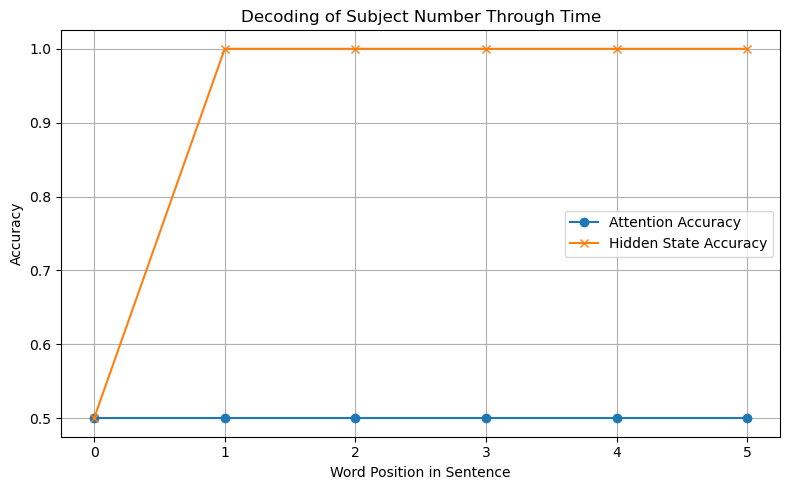

In [32]:
import matplotlib.pyplot as plt

# Time axis
time_steps = list(range(seq_len))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(time_steps, att_accs, label='Attention Accuracy', marker='o')
plt.plot(time_steps, hid_accs, label='Hidden State Accuracy', marker='x')

plt.title('Decoding of Subject Number Through Time')
plt.xlabel('Word Position in Sentence')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import defaultdict

# Flatten & prepare
flat_conditions = [cond for batch in features['condition'] for cond in batch]
flat_conditions_np = np.array(flat_conditions)
targets = np.array(targets)
unique_conds = sorted(set(flat_conditions))
# Hidden state formatting
hidden_batches = []
for batch_hidden in features['hidden']:
    hidden_seq = torch.stack(batch_hidden, dim=0)  # (seq_len, batch_size, dim)
    hidden_seq = hidden_seq.permute(1, 0, 2)       # (batch_size, seq_len, dim)
    hidden_batches.append(hidden_seq)
hidden_all = torch.cat(hidden_batches, dim=0).cpu().numpy()  # (N, seq_len, dim)

attention_batches = []

for batch_attention in features['attention_weights']:
    att_seq = []
    for i in range(len(batch_attention)):
        # Shape: (batch_size, 1, 1, i+1)
        att = batch_attention[i].squeeze()  # shape: (batch_size, i+1)
        if att.ndim == 1:
            att = att.unsqueeze(-1)  # ensure shape: (batch_size, 1)
        last_val = att[:, -1]       # take only the last token’s attention value
        att_seq.append(last_val)    # shape: (batch_size,)

    # Stack across sequence steps: (seq_len, batch_size)
    att_seq = torch.stack(att_seq, dim=0)

    # Permute to (batch_size, seq_len)
    att_seq = att_seq.permute(1, 0)

    attention_batches.append(att_seq)

# Final attention tensor: (N, seq_len)
attention_all = torch.cat(attention_batches, dim=0).cpu().numpy()



# Train-test split
train_idx, test_idx = train_test_split(
    np.arange(len(flat_conditions_np)),
    test_size=0.3,
    stratify=flat_conditions_np,
    random_state=42
)

# Prepare split sets
hidden_train, hidden_test = hidden_all[train_idx], hidden_all[test_idx]
attention_train, attention_test = attention_all[train_idx], attention_all[test_idx]
targets_train, targets_test = targets[train_idx], targets[test_idx]
conds_test = flat_conditions_np[test_idx]

# Initialize results
seq_len = hidden_train.shape[1]
results_hidden = defaultdict(list)   # key: condition, value: list of acc over time
results_attention = defaultdict(list)

# Loop over time steps
for t in range(seq_len):
    # Train on full training set
    clf_hidden = LogisticRegression(max_iter=1000)
    clf_hidden.fit(hidden_train[:, t], targets_train)
    hidden_preds = clf_hidden.predict(hidden_test[:, t])

    clf_att = LogisticRegression(max_iter=1000)
    clf_att.fit(attention_train[:, t].reshape(-1, 1), targets_train)
    attention_preds = clf_att.predict(attention_test[:, t].reshape(-1, 1))

    # Compute per-condition accuracy
    for cond in unique_conds:
        cond_mask = np.array(conds_test) == cond
        acc_hid = accuracy_score(targets_test[cond_mask], hidden_preds[cond_mask])
        acc_att = accuracy_score(targets_test[cond_mask], attention_preds[cond_mask])
        results_hidden[cond].append(acc_hid)
        results_attention[cond].append(acc_att)


In [34]:
results_attention.keys(
    
)

dict_keys(['plural plural', 'plural singular', 'singular plural', 'singular singular'])

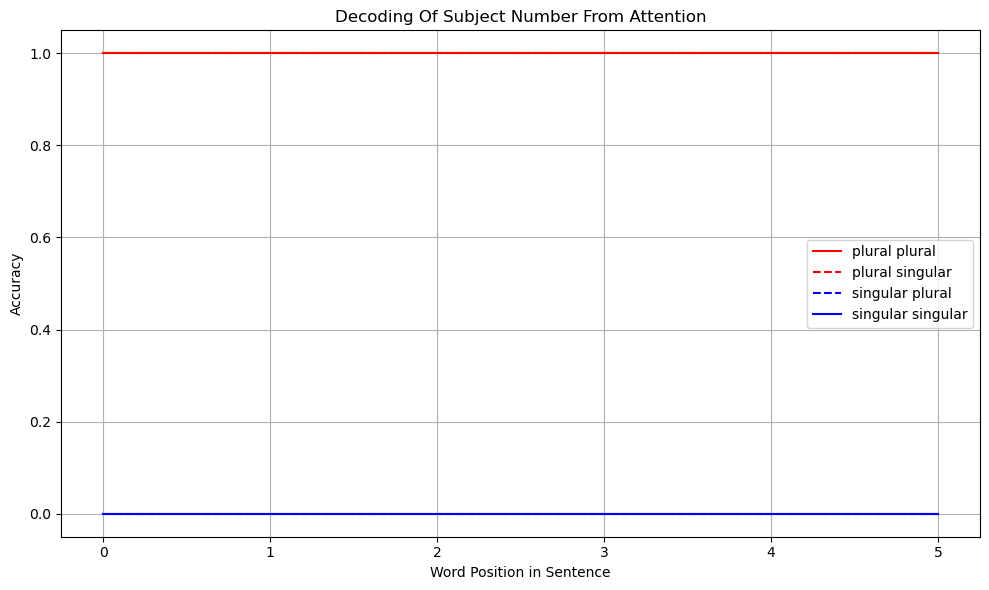

In [35]:
import matplotlib.pyplot as plt

# Define style mapping
style_map = {
    'singular singular': {'color': 'blue', 'linestyle': '-'},
    'singular plural': {'color': 'blue', 'linestyle': '--'},
    'plural plural': {'color': 'red', 'linestyle': '-'},
    'plural singular': {'color': 'red', 'linestyle': '--'},
}

plt.figure(figsize=(10, 6))
time_steps = list(range(seq_len))

for cond in unique_conds:
    style = style_map.get(cond, {'color': 'black', 'linestyle': ':'})

    
    # Attention
    plt.plot(
        time_steps,
        results_attention[cond],
        label=f'{cond}',
        color=style['color'],
        linestyle=style['linestyle'],
        #alpha=0.3
    )

plt.title("Decoding Of Subject Number From Attention")
plt.xlabel("Word Position in Sentence")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [270]:
attention_batches = []

for batch_attention in features['attention_weights']:
    att_seq = []
    for i in range(len(batch_attention)):
        # Shape: (batch_size, 1, 1, i+1)
        att = batch_attention[i].squeeze()  # shape: (batch_size, i+1)
        if att.ndim == 1:
            att = att.unsqueeze(-1)  # ensure shape: (batch_size, 1)
        last_val = att[:, -1]       # take only the last token’s attention value
        att_seq.append(last_val)    # shape: (batch_size,)

    # Stack across sequence steps: (seq_len, batch_size)
    att_seq = torch.stack(att_seq, dim=0)

    # Permute to (batch_size, seq_len)
    att_seq = att_seq.permute(1, 0)

    attention_batches.append(att_seq)

# Final attention tensor: (N, seq_len)
attention_all = torch.cat(attention_batches, dim=0).cpu().numpy()



In [271]:
attention_all.shape

(4000, 6)